In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd drive/MyDrive/ParkingLotDetector_tool/

/content/drive/MyDrive/ParkingLotDetector_tool


In [4]:
pwd

'/content/drive/MyDrive/ParkingLotDetector_tool'

In [5]:
!pip install -q "pytorch-lightning<2.0.0"
!pip install -q transformers datasets roboflow
!pip install -q evaluate rasterio geojson

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.6/931.6 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import imageio.v2 as iio
import numpy as np
import multiprocessing as mp
from PIL import Image
import torchmetrics as tm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as tf
import torchvision.models.segmentation
import shapely
from PIL import ImageFilter
from numpy import asarray
from scipy.ndimage import measurements
from shapely import Polygon, LineString, MultiPolygon, Point
from shapely.validation import explain_validity
import geopandas as gpd
from shapely.geometry import Polygon, box
import subprocess
from shapely.ops import unary_union
import rasterio
from pyproj import Transformer
from geojson import Feature, FeatureCollection, LineString
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np
from torchvision.transforms import functional as F
import torchvision.transforms as transforms
from tqdm import tqdm
import huggingface_hub
import warnings
warnings.filterwarnings("ignore")

In [7]:
from functions import convert_to_rgb, split_images, detect_polygons_inside, find_polygons, pixels_to_coordinates, poly_list_to_geojson
from inference import SemanticSegmentationDataset, SegformerFinetuner, get_pred_segformer
from post_processing import remove_buildings, remove_roads, get_building_data, osm_to_geojson, get_road_data

# To Do:

In [8]:
file_name = 'files/la_22.tif' # Replace with the path to your tif image
name = "la_22" # Replace with the prefered name for the output files

# STEP 1: Calculate Latitudes and Longitudes

In [9]:
# Finding lons and lats from tif image
# Step 1: Read the input image
with rasterio.open(file_name) as dataset:
    # Get image dimensions
    height, width = dataset.height, dataset.width

    # Generate grid of pixel indices (row, col)
    row_indices, col_indices = np.meshgrid(range(height), range(width), indexing="ij")

    # Transform pixel indices to lat/lon
    transform = dataset.transform
    lon, lat = rasterio.transform.xy(transform, row_indices, col_indices, offset="center")

    # Convert results to numpy arrays
    lat = np.array(lat).reshape(height, width)
    lon = np.array(lon).reshape(height, width)

print("Latitude shape:", lat.shape)
print("Longitude shape:", lon.shape)

Latitude shape: (8677, 7995)
Longitude shape: (8677, 7995)


# STEP 2: Split large image into 512*512 images

In [10]:
# Spliting the image into small images with size 512*512 to be ready for prediction
height = width =512
count = 0
rgb_path = 'files/large_img.PNG'
convert_to_rgb(file_name, rgb_path)
img = iio.imread(rgb_path)
count , img_shp1, img_shp2 = split_images(img, num = count)
print(img_shp1)
print(img_shp2)
lons = lon[:img_shp1,:img_shp2]
lats = lat[:img_shp1,:img_shp2]
if img_shp1 > lons.shape[0]:
    pad_width = ((0, img_shp1 - lons.shape[0]), (0, 0))
    lons = np.pad(lons, pad_width, mode='edge')
    lats = np.pad(lats, pad_width, mode='edge')
if img_shp2 > lons.shape[1]:
    pad_width = ((0, 0), (0, img_shp2 - lons.shape[1]))
    lons = np.pad(lons, pad_width, mode='edge')
    lats = np.pad(lats, pad_width, mode='edge')

8704
8192


# STEP 3: Get predictions

In [14]:
from torch.utils.data import DataLoader
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from tqdm import tqdm
import torch
import numpy as np

# Function to process a batch of images
def process_batch(batch):
    images, masks = batch['pixel_values'], batch['labels']
    images = images.cuda()
    masks = masks.cuda()
    with torch.no_grad():
        outputs = segformer_finetuner.model(images, masks)
        logits = outputs[1]
        upsampled_logits = nn.functional.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        predicted_mask = upsampled_logits.argmax(dim=1).cpu().numpy()
    return predicted_mask

def save_mask(img_number, mask):
    img_name = test_dataset.imgs[img_number].split('.')[0]
    Image.fromarray(mask.astype(np.uint8)).save('small_images/Masks/' + img_name + '.PNG', "PNG", quality=100)

In [ ]:
from huggingface_hub import hf_hub_download
import shutil, os

repo_id = "UTEL-UIUC/SegFormer-large-parking"

cached_file = hf_hub_download(repo_id=repo_id, filename="best_model.ckpt")

shutil.copy(cached_file, "files/best_model.ckpt")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b5-finetuned-cityscapes-1024-1024 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([19, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([19]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b5-finetuned-cityscapes-1024-1024 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([19, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.

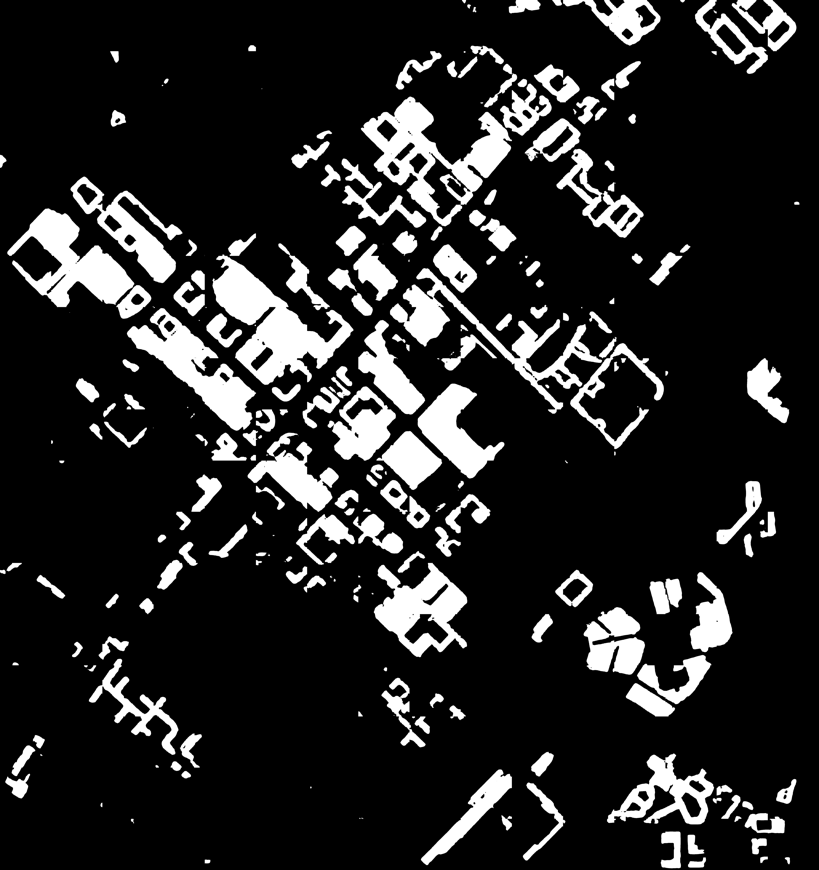

In [15]:
feature_extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b5-finetuned-cityscapes-1024-1024")
feature_extractor.do_reduce_labels = False
feature_extractor.size = 512

seg_t = np.zeros((img_shp1, img_shp2))
n_r = img_shp1 // 512
n_c = img_shp2 // 512

test_dataset = SemanticSegmentationDataset("small_images/", feature_extractor)

batch_size = 5  # Increase batch size if GPU memory allows
num_workers = 4  # Increase the number of workers for data loading
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)

path = 'files/best_model.ckpt'
segformer_finetuner = SegformerFinetuner(
    test_dataset.id2label,
    train_dataloader=test_dataloader,
    val_dataloader=test_dataloader,
    test_dataloader=test_dataloader,
    metrics_interval=10,
).load_from_checkpoint(path, id2label=test_dataset.id2label)

# Move model to GPU and use DataParallel if multiple GPUs are available
if torch.cuda.device_count() > 1:
    segformer_finetuner.model = nn.DataParallel(segformer_finetuner.model)
segformer_finetuner.model.cuda()

# Process images in batches
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    futures = []
    for batch_idx, batch in enumerate(tqdm(test_dataloader, desc="Processing images")):
        masks = process_batch(batch)
        for i in range(masks.shape[0]):
            img_number = batch_idx * batch_size + i
            futures.append(executor.submit(save_mask, img_number, masks[i]))

    # Wait for all futures to complete
    for future in futures:
        future.result()

# Assemble the final segmentation map
for img_number in range(count):
    rr = img_number // n_c
    cc = img_number % n_c
    pred = Image.open('small_images/Masks/' + str(img_number+1) + '.PNG')
    seg_t[rr*512:(rr+1)*512, cc*512:(cc+1)*512] = pred


seg_image = (seg_t*255)
im = Image.fromarray(seg_image).convert('RGB')
im.resize((int(img_shp2/10), int(img_shp1/10)))

# STEP 4: Convert predicted images to a single GeoJSON file

In [16]:
# Converting large mask to polygons
Polys, inner_polygons = find_polygons(seg_t)
Polys_coord = pixels_to_coordinates(Polys, lons, lats)
inner_coord = pixels_to_coordinates(inner_polygons, lons, lats)

# Saving polygons in shape file format
os.makedirs("output_files", exist_ok=True)
output_path = 'output_files/' + name + '_original.geojson'
poly_list_to_geojson(Polys_coord, inner_coord, output_path)

# STEP 5: Post-processing 1: Simplifying the Edges
To perform the simplification, follow these steps:

1. Install Node.js if you haven't already.

2. Install mapshaper using the command: npm install -g mapshaper

You can skip this part if you don't want to install mapshaper but make sure that you change the name of the parking path file in the second cell of the STEP 6.

In [ ]:
# command = "mapshaper output_files/" + name + "_original.geojson -simplify 20% -o output_files/" + name + "_simp.shp"

# result = subprocess.run(command, shell=True, check=False, capture_output=True)
# print(result.stdout.decode())
# print(result.stderr.decode())


[o] Unable to generate .prj file for chicago2_simp.shp
[o] Wrote output_files\chicago2_simp.shp
[o] Wrote output_files\chicago2_simp.shx
[o] Wrote output_files\chicago2_simp.dbf



# STEP 6: Post-processing 2: Building Removal

First we need to download building dataset from Microsoft Building Footprints.

In [18]:
# Load US States shapefile (adjust the path to your shapefile)
states = gpd.read_file("files/tl_2024_us_state.geojson")

# Ensure CRS (Coordinate Reference System) matches
states = states.to_crs(epsg=3857)

point = Point(lons[0][0], lats[0][0]) # One point from the test area

# Check which state contains the point
for _, state in states.iterrows():
    if state.geometry.contains(point):
        print(state['NAME'])
        break
else:
    print("The point is not in any state.")

# Folder where the building datasets are stored
dataset_folder = "building_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Path to the CSV file containing state names and URLs
csv_file = "files/building_links.csv"

state_name = state['NAME']
get_building_data(state_name, dataset_folder, csv_file)

Louisiana
Downloaded building_dataset/Louisiana.geojson.zip.
Extracted building_dataset/Louisiana.geojson.zip.


With the building data in hand, we proceed to remove any misclassified buildings. Please note that this step may take some time, as we need to first load the building data for the entire state.

Note: If you skipped the simplification step, update the first line of the next cell as follows:

parking_path = 'output_files/' + name + '_original.geojson'

In [19]:
parking_path = 'output_files/' + name + '_original.geojson'
# parking_path = 'output_files/' + name + '_simp.shp'
formatted_state_name = state_name.replace(" ", "") if " " in state_name else state_name
building_path = 'building_dataset/' + formatted_state_name+ '.geojson'
build_state = gpd.read_file(building_path)
with rasterio.open(file_name) as src:
    bounds = src.bounds  # (minx, miny, maxx, maxy)
    bbox = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]})
bbox_gdf.set_geometry("geometry", inplace=True)
bbox_gdf.set_crs('EPSG:3857', inplace=True)
bbox_gdf.to_crs(build_state.crs, inplace=True)
buildings = build_state[build_state.intersects(bbox_gdf.geometry.iloc[0], align=True)]
buildings = buildings.iloc[0:0]
output_path = 'output_files/' + name + '_build.shp'
remove_buildings(parking_path, buildings, output_path)

# STEP 7: Post-processing 3: Road Removal

First we need to download and modify road dataset from OpenStreetMap.

In [20]:
# Open TIFF file
with rasterio.open(file_name) as dataset:
    # Get bounding box in original CRS
    bbox = dataset.bounds  # BoundingBox(left, bottom, right, top)
    src_crs = dataset.crs  # Get CRS from the TIF file

# Define target CRS (Lat/Lon)
dst_crs = "EPSG:4326"

# Initialize transformer
transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

# Convert bounding box coordinates
min_lon, min_lat = transformer.transform(bbox.left, bbox.bottom)  # Bottom-left corner
max_lon, max_lat = transformer.transform(bbox.right, bbox.top)  # Top-right corner

# New bbox in Lat/Lon format
converted_bbox = [min_lat, min_lon, max_lat, max_lon]
print(converted_bbox)

# Get road data
get_road_data(converted_bbox)

[30.144381998622237, -92.05735435599549, 30.167715835410075, -92.0324892991128]
GeoJSON saved to files/road_data.geojson


With the road data in hand, we proceed to remove any misclassified roads.

In [21]:
parking_path = 'output_files/' + name + '_build.shp'
road_path = 'files/road_data.geojson'
output_path = 'output_files/' + name + '_road.shp'
remove_roads(parking_path, road_path, output_path)

# STEP 8: Post-processing 4: Holes and Islands Removal

In [22]:
file_path = 'output_files/' + name + '_road.shp'
gdf = gpd.read_file(file_path)
gdf_exploded = gdf.explode(index_parts=False).reset_index(drop=True)
gdf_exploded = gdf_exploded.to_crs(epsg=3857)
gdf_all = gdf_exploded[gdf_exploded['geometry'].area > 300]
gdf_all = gdf_all.to_crs(epsg=4326)
gdf_all.to_file('output_files/' + name + '_all.geojson', driver='GeoJSON')

Now, in the output_files folder, you will see the outputs with the following filenames:

- *Original prediction file:* name + "_original.geojson"
- *Simlifyed Edges prediction file:* name + "_simp.shp"
- *Building corrected prediction file:* name + "_build.shp"
- *Road corrected prediction file:* name + "_road.geojson"
- *Predictions with all the post-processing:* name + "_all.geojson"